# Graficos do Merge Sort em C

Este notebook mostra os resultados medidos da implementacao em C.

O objetivo e comparar os tres cenarios do projeto:
- Melhor Caso
- Caso Medio
- Pior Caso

Assim como no notebook de Python, o eixo Y sera exibido em escala logaritmica para permitir a leitura conjunta dos tres tamanhos analisados.

## 1. Importacoes

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Caminhos e configuracao visual

Definimos os caminhos dos arquivos e padronizamos o visual para ficar parecido com a analise em Python.

In [2]:
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

ROOT = Path('..').resolve()
RESULTS_DIR = ROOT / 'results'
GRAPHS_DIR = ROOT / 'graphs'
GRAPHS_DIR.mkdir(exist_ok=True)

TAMANHO_ORDEM = ['pequeno', 'medio', 'grande']
CENARIO_ORDEM = ['melhor_caso', 'caso_medio', 'pior_caso']

ROTULOS_CENARIO = {
    'melhor_caso': 'Melhor Caso',
    'caso_medio': 'Caso Medio',
    'pior_caso': 'Pior Caso',
}

CORES_CENARIO = {
    'melhor_caso': '#2E86AB',
    'caso_medio': '#F18F01',
    'pior_caso': '#C73E1D',
}

## 3. Leitura dos dados

Aqui lemos o CSV gerado pelo benchmark em C e organizamos os tamanhos na ordem correta.

In [3]:
# Le o arquivo de resultados gerado pelo benchmark em C.
df_c = pd.read_csv(RESULTS_DIR / 'c_results.csv')

# Define a ordem dos tamanhos para manter a visualizacao consistente.
df_c['tamanho'] = pd.Categorical(df_c['tamanho'], categories=TAMANHO_ORDEM, ordered=True)
df_c = df_c.sort_values(['tamanho', 'cenario']).reset_index(drop=True)

In [4]:
df_c

,linguagem,cenario,tamanho,n,media_ms,desvio_ms,min_ms,max_ms,rodadas
0,C,caso_medio,pequeno,1000,0.1763,0.0468,0.1659,0.4236,30
1,C,melhor_caso,pequeno,1000,0.1542,0.0500,0.1175,0.3603,30
2,C,pior_caso,pequeno,1000,0.1216,0.0396,0.1077,0.3236,30
3,C,caso_medio,medio,10000,2.6364,0.6737,1.9049,4.5247,30
4,C,melhor_caso,medio,10000,1.7182,0.3743,1.3798,2.4782,30
5,C,pior_caso,medio,10000,1.7256,0.4780,1.2305,3.0863,30
6,C,caso_medio,grande,100000,27.5330,11.4657,20.0015,62.0373,30
7,C,melhor_caso,grande,100000,17.3820,1.9626,13.9280,21.4555,30
8,C,pior_caso,grande,100000,19.3469,12.2353,14.7020,80.8221,30


## 4. Preparacao dos dados

Nesta etapa deixamos os tres cenarios lado a lado e montamos rotulos mais claros para o eixo X.

In [5]:
# Monta uma tabela em que cada coluna representa um cenario.
tabela_c = (
    df_c.pivot(index='tamanho', columns='cenario', values='media_ms')
    .reindex(TAMANHO_ORDEM)
    .reindex(columns=CENARIO_ORDEM)
)

# Busca o valor real de n para mostrar junto com o nome do tamanho.
n_por_tamanho = (
    df_c[['tamanho', 'n']]
    .drop_duplicates()
    .set_index('tamanho')['n']
    .to_dict()
)

rotulos_tamanho = [
    f"Pequeno ({n_por_tamanho['pequeno']})",
    f"Medio ({n_por_tamanho['medio']})",
    f"Grande ({n_por_tamanho['grande']})",
]

tabela_c

cenario,melhor_caso,caso_medio,pior_caso
tamanho,,,
pequeno,0.1542,0.1763,0.1216
medio,1.7182,2.6364,1.7256
grande,17.3820,27.5330,19.3469


## 5. Grafico principal

Neste grafico, comparamos o tempo medio de execucao do Merge Sort em C nos cenarios de Melhor Caso, Caso Medio e Pior Caso.

- Eixo X: mostra o tamanho da entrada testada e, entre parenteses, o valor de `n` usado em cada grupo.
- Eixo Y: mostra o tempo medio de execucao em milissegundos.
- Foi usada escala logaritmica no eixo Y porque os tempos medidos para entradas maiores ficam muito acima dos tempos de entradas menores.
- Por isso, marcas como `10^0`, `10^1` e `10^2` representam potencias de 10 em milissegundos e ajudam a comparar valores pequenos e grandes no mesmo grafico.
- O ponto principal da leitura e observar como o tempo cresce com o aumento de `n` e verificar se os tres cenarios mantem comportamento parecido.

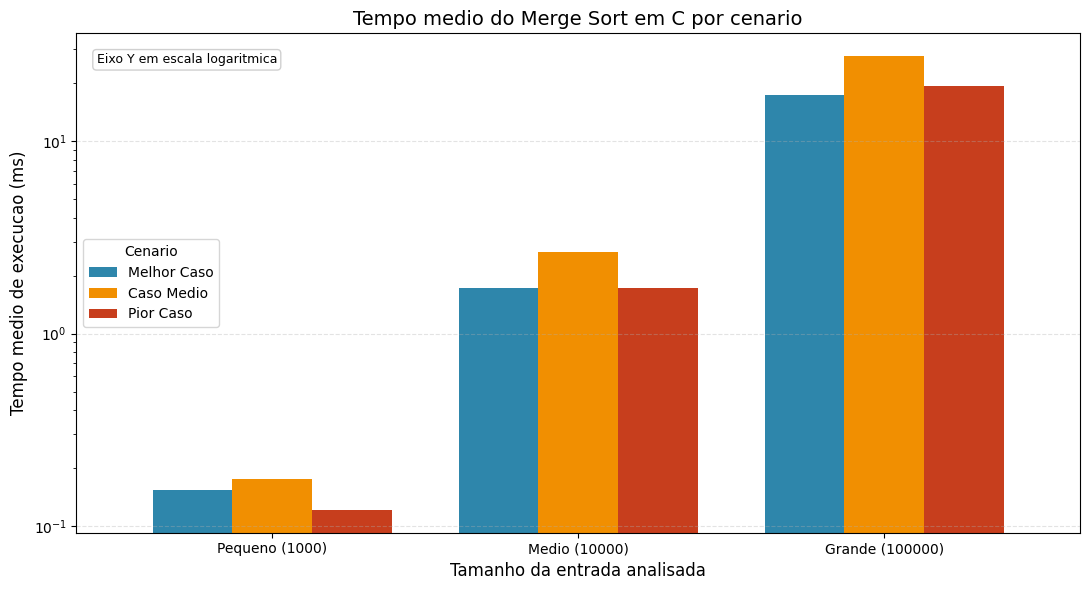

In [6]:
# Cria o grafico de barras agrupadas com a mesma paleta usada no notebook de Python.
ax = tabela_c.plot(
    kind='bar',
    color=[CORES_CENARIO[cenario] for cenario in CENARIO_ORDEM],
    width=0.78,
)

# Ajusta titulo, eixos e legenda com nomes mais amigaveis.
ax.set_title('Tempo medio do Merge Sort em C por cenario')
ax.set_xlabel('Tamanho da entrada analisada')
ax.set_ylabel('Tempo medio de execucao (ms)')
ax.set_xticklabels(rotulos_tamanho, rotation=0)
ax.set_yscale('log')
ax.legend([ROTULOS_CENARIO[cenario] for cenario in CENARIO_ORDEM], title='Cenario')

# Adiciona grade leve e uma nota curta sobre a escala logaritmica.
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.text(
    0.02,
    0.96,
    'Eixo Y em escala logaritmica',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'c_cenarios.png', dpi=200)
plt.show()
plt.close()